Purpose: Look at flowering & fruiting data Kylie Hays collected from iNaturalist for all three *Yucca* species.<br>
Author: Anna Pardo<br>
Date initiated: May 28, 2026

In [47]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import calendar
import seaborn as sns

In [2]:
# load iNaturalist data
ygin = pd.read_csv("./inat_data_Yg.csv",sep=",",header="infer")
ygin = ygin.rename(columns={"Unnamed: 4":"Fruit"})
ygin["Species"] = "Y. gloriosa"
ygin.head()

,Species,Date,Location,Flowering,Fruit,Budding,Lat/Lon,Link,Notes
0,Y. gloriosa,9/13/2008,"Georgetown County, SC",Yes,No,Yes,"33.551738, -79.018066",https://www.inaturalist.org/observations/85415489,NaN
1,Y. gloriosa,11/4/2011,"Sullivan's Island, SC",Yes,No,No,"32.7605183951, -79.8323464394",https://www.inaturalist.org/observations/14347...,NaN
2,Y. gloriosa,4/29/2015,"Beaufort County, SC",Yes,No,No,"32.403785348, -80.4281096359",https://www.inaturalist.org/observations/14647...,NaN
3,Y. gloriosa,8/8/2015,"Hilton Head Island, SC",Yes,No,No,"32.2520833333, -80.7012555556",https://www.inaturalist.org/observations/7368593,NaN
4,Y. gloriosa,10/25/2016,"Hilton Head Island, SC",Yes,No,Yes,"32.2063055556, -80.6819527778",https://www.inaturalist.org/observations/7425346,NaN


In [3]:
# load further Yg iNat data from Karolina
kh_ygin = pd.read_excel("./yucca_gloriosa_NCflowering.xlsx")
kh_ygin.head()

,Species,Month,Year,Location,Flowering,Fruit,Budding,Lat/Lon,Link,Notes
0,Y. gloriosa,Oct,2025,Outer banks,1,0,1,"35.29181, -75.54685",https://www.inaturalist.org/observations/32263...,NaN
1,Y. gloriosa,Oct,2025,Outer banks,1,0,1,"35.38328, -75.70712",https://www.inaturalist.org/observations/32054...,NaN
2,Y. gloriosa,Aug,2025,Nags Head,1,0,1,"35.96634, -75.73077",https://www.inaturalist.org/observations/30555...,NaN
3,Y. gloriosa,Oct,2024,Cape Hatteras,1,0,1,"35.34943, -75.49205",https://www.inaturalist.org/observations/24702...,NaN
4,Y. gloriosa,May,2024,Kill Devil Hills,1,0,1,"36.03585, -75.67451",https://www.inaturalist.org/observations/21633...,NaN


In [4]:
kh_ygin["Species"] = "Y. gloriosa"

In [5]:
yain = pd.read_csv("./inat_data_Ya.csv",sep=",",header="infer")
yain.head()

,Species,Date,Location,Flowering,Fruit,Budding,Lat/Lon,Link,Notes
0,Y. aloifolia,5/26/2010,"St. Johns County, FL",Yes,No,No,"30.0293864747, -81.3362822722",https://www.inaturalist.org/observations/17208...,NaN
1,Y. aloifolia,5/9/2013,"Bradenton, FL",Yes,No,Yes,"27.521692, -82.643475",https://www.inaturalist.org/observations/260901,NaN
2,Y. aloifolia,5/11/2013,"Punta Gorda, FL",Yes,No,Yes,"26.915702, -82.091372",https://www.inaturalist.org/observations/264005,NaN
3,Y. aloifolia,4/24/2014,"Palma Sola, FL",Yes,No,Yes,"27.51226, -82.632043",https://www.inaturalist.org/observations/886700,NaN
4,Y. aloifolia,4/25/2014,"Bradenton, FL",No,No,Yes,"27.4650166667, -82.6471166667",https://www.inaturalist.org/observations/682210,NaN


In [6]:
yfin = pd.read_csv("./inat_data_Yf.csv",sep=",",header="infer")
yfin.head()

,Species,Date,Location,Flowering,Fruit,Budding,Lat/Lon,Link,Notes
0,Y. filamentosa,5/2/2011,"Duval, FL",Yes,No,Yes,"30.4369433333, -81.4129033333",https://www.inaturalist.org/observations/86795741,NaN
1,Y. filamentosa,5/30/2013,"Richland County, SC",Yes,No,Yes,"33.7918510001, -80.7490487024",https://www.inaturalist.org/observations/14444...,NaN
2,Y. filamentosa,5/10/2015,"Citrus County, FL",Yes,No,Yes,"28.7784954008, -82.5829182456",https://www.inaturalist.org/observations/40839097,NaN
3,Y. filamentosa,6/13/2016,"Okaloosa County, FL",No,Yes,No,"30.384673, -86.443995",https://www.inaturalist.org/observations/3534235,NaN
4,Y. filamentosa,5/7/2017,"Sullivan's Island, SC",Yes,No,No,"32.7583351135, -79.8561096191",https://www.inaturalist.org/observations/6258820,NaN


In [7]:
kh_ygin["Month"].unique()

array(['Oct', 'Aug', 'May', 'Nov', 'Sep', 'Dec', 'April', 'December',
       'November', 'October', 'September', 'August', 'July', 'June',
       'February', 'Jan', 'January', 'March'], dtype=object)

In [8]:
month_num = {
    "1":"Jan",
    "2":"Feb",
    "3":"Mar",
    "4":"Apr",
    "5":"May",
    "6":"Jun",
    "7":"Jul",
    "8":"Aug",
    "9":"Sep",
    "10":"Oct",
    "11":"Nov",
    "12":"Dec"
} 

In [9]:
kh_ygin.head()

,Species,Month,Year,Location,Flowering,Fruit,Budding,Lat/Lon,Link,Notes
0,Y. gloriosa,Oct,2025,Outer banks,1,0,1,"35.29181, -75.54685",https://www.inaturalist.org/observations/32263...,NaN
1,Y. gloriosa,Oct,2025,Outer banks,1,0,1,"35.38328, -75.70712",https://www.inaturalist.org/observations/32054...,NaN
2,Y. gloriosa,Aug,2025,Nags Head,1,0,1,"35.96634, -75.73077",https://www.inaturalist.org/observations/30555...,NaN
3,Y. gloriosa,Oct,2024,Cape Hatteras,1,0,1,"35.34943, -75.49205",https://www.inaturalist.org/observations/24702...,NaN
4,Y. gloriosa,May,2024,Kill Devil Hills,1,0,1,"36.03585, -75.67451",https://www.inaturalist.org/observations/21633...,NaN


In [10]:
# convert Year to a string column
kh_ygin["Year"] = kh_ygin["Year"].astype(str)

In [11]:
# split date info in ygin, yfin, and yain into Month and Year columns
def format_month_year(df):
    df["Month"] = df["Date"].str.split("/").str[0]
    df["Year"] = df["Date"].str.split("/").str[2]
    df["Month"] = df["Month"].map(month_num)
    return df[["Species","Month","Year","Flowering","Fruit","Budding","Lat/Lon"]]

In [12]:
yain = format_month_year(yain)
yfin = format_month_year(yfin)
ygin = format_month_year(ygin)

In [13]:
kh_ygin = kh_ygin[["Species","Month","Year","Flowering","Fruit","Budding","Lat/Lon"]]

In [14]:
month_map = {}
for i in kh_ygin["Month"].unique():
    if len(i)>3:
        month_map[i] = i[0:3]
    else:
        month_map[i] = i

In [15]:
kh_ygin["Month"] = kh_ygin["Month"].map(month_map)
kh_ygin.head()

,Species,Month,Year,Flowering,Fruit,Budding,Lat/Lon
0,Y. gloriosa,Oct,2025,1,0,1,"35.29181, -75.54685"
1,Y. gloriosa,Oct,2025,1,0,1,"35.38328, -75.70712"
2,Y. gloriosa,Aug,2025,1,0,1,"35.96634, -75.73077"
3,Y. gloriosa,Oct,2024,1,0,1,"35.34943, -75.49205"
4,Y. gloriosa,May,2024,1,0,1,"36.03585, -75.67451"


In [16]:
# stick all data together
inat = pd.concat([yain,yfin,ygin,kh_ygin])
len(inat.index)

566

In [17]:
inat = inat.drop_duplicates()
len(inat.index)

555

In [18]:
inat["Flowering"].fillna("No",inplace=True)
inat["Flowering"] = inat["Flowering"].map({"Yes":"Yes","No":"No","No ":"No"})
inat["Flowering"].unique()

array(['Yes', 'No', nan], dtype=object)

In [19]:
inat["Flowering"].fillna("No",inplace=True)
inat["Flowering"].unique()

array(['Yes', 'No'], dtype=object)

In [20]:
inat["Fruit"].fillna("No",inplace=True)
inat["Fruit"] = inat["Fruit"].map({"Yes":"Yes","No":"No",0:"No"})
inat["Fruit"].unique()

array(['No', 'Yes'], dtype=object)

In [21]:
inat["Budding"].fillna("No",inplace=True)
inat["Budding"] = inat["Budding"].map({"Yes":"Yes","No":"No",1:"Yes",0:"No"})
inat["Budding"].unique()

array(['No', 'Yes'], dtype=object)

In [22]:
# split lat & long into separate columns
inat["Latitude"] = inat["Lat/Lon"].str.split(",").str[0].astype(float)
inat["Longitude"] = inat["Lat/Lon"].str.split(", ").str[1].astype(float)
inat.head()

,Species,Month,Year,Flowering,Fruit,Budding,Lat/Lon,Latitude,Longitude
0,Y. aloifolia,May,2010,Yes,No,No,"30.0293864747, -81.3362822722",30.029386,-81.336282
1,Y. aloifolia,May,2013,Yes,No,Yes,"27.521692, -82.643475",27.521692,-82.643475
2,Y. aloifolia,May,2013,Yes,No,Yes,"26.915702, -82.091372",26.915702,-82.091372
3,Y. aloifolia,Apr,2014,Yes,No,Yes,"27.51226, -82.632043",27.512260,-82.632043
4,Y. aloifolia,Apr,2014,No,No,Yes,"27.4650166667, -82.6471166667",27.465017,-82.647117


In [23]:
# make a GeoDataFrame 
df = inat[["Species","Month","Year","Flowering","Fruit","Budding","Latitude","Longitude"]]
gdf = gpd.GeoDataFrame(df,geometry=gpd.points_from_xy(df.Longitude,df.Latitude),crs="EPSG:4326")

In [35]:
df.head()

,Species,Month,Year,Flowering,Fruit,Budding,Latitude,Longitude
0,Y. aloifolia,May,2010,Yes,No,No,30.029386,-81.336282
1,Y. aloifolia,May,2013,Yes,No,Yes,27.521692,-82.643475
2,Y. aloifolia,May,2013,Yes,No,Yes,26.915702,-82.091372
3,Y. aloifolia,Apr,2014,Yes,No,Yes,27.512260,-82.632043
4,Y. aloifolia,Apr,2014,No,No,Yes,27.465017,-82.647117


In [36]:
# save unified iNaturalist data
df.to_csv("./iNaturalist_obs_all.csv",sep=",",header=True,index=False)

In [24]:
gdf.head()

,Species,Month,Year,Flowering,Fruit,Budding,Latitude,Longitude,geometry
0,Y. aloifolia,May,2010,Yes,No,No,30.029386,-81.336282,POINT (-81.33628 30.02939)
1,Y. aloifolia,May,2013,Yes,No,Yes,27.521692,-82.643475,POINT (-82.64347 27.52169)
2,Y. aloifolia,May,2013,Yes,No,Yes,26.915702,-82.091372,POINT (-82.09137 26.91570)
3,Y. aloifolia,Apr,2014,Yes,No,Yes,27.512260,-82.632043,POINT (-82.63204 27.51226)
4,Y. aloifolia,Apr,2014,No,No,Yes,27.465017,-82.647117,POINT (-82.64712 27.46502)


In [25]:
# load US state borders map
kml_file = "./cb_2018_us_state_500k/cb_2018_us_state_500k.kml"

states = gpd.read_file(
    kml_file,
    driver="KML",
    engine="pyogrio"
)

In [26]:
gdf["Month"] = pd.Categorical(gdf["Month"],
                             categories=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
                             ordered=True)

In [27]:
gdf = gdf.sort_values("Month",ignore_index=True)

In [28]:
# subset to flowering=Yes, fruit=Yes, and budding=Yes (separately)
flower = gdf[gdf["Flowering"]=="Yes"]
fruit = gdf[gdf["Fruit"]=="Yes"]
bud = gdf[gdf["Budding"]=="Yes"]

In [29]:
# change marker styles by species
marker_dict = {
    "Y. aloifolia": "o",
    "Y. filamentosa": "^",
    "Y. gloriosa": "s"
}

In [30]:
# create a custom discrete colormap: group by meterological season 
season_map = mcolors.ListedColormap(["dodgerblue","blue",
                              "olivedrab","darkolivegreen","darkgreen",
                              "orchid","magenta","crimson",
                              "coral","sienna","saddlebrown",
                              "darkturquoise"])


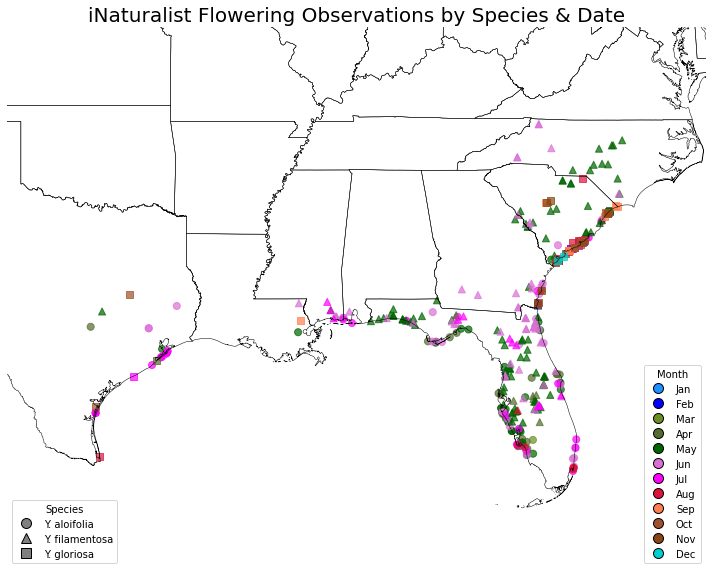

In [31]:
fig, ax = plt.subplots(figsize=(10,10))

states.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

# plot each species separately
for species, marker in marker_dict.items():

    sub = flower[flower["Species"] == species]

    sub.plot(
        ax=ax,
        column="Month",
        cmap=season_map,
        marker=marker,
        markersize=50,
        alpha=0.7,
        legend=False
    )

handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle="",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=10,
        label=species
    )
    for species, marker in marker_dict.items()
]

species_legend = ax.legend(
    handles=handles,
    title="Species",
    loc="lower left"
)
ax.add_artist(species_legend)

cmap = plt.get_cmap(season_map)

month_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=cmap((m-1)/11),
        markeredgecolor="black",
        markersize=10,
        label=calendar.month_abbr[m]
    )
    for m in range(1, 13)
]

ax.legend(
    handles=month_handles,
    title="Month",
    loc="lower right"
)

xmin, ymin, xmax, ymax = flower.total_bounds

ax.set_xlim(xmin - 3, xmax + 3)
ax.set_ylim(ymin - 3, ymax + 3)

ax.set_axis_off()

plt.title("iNaturalist Flowering Observations by Species & Date",fontsize=20)
plt.tight_layout()

plt.savefig("./inat_flowering_map.png",dpi=300,bbox_inches="tight")
plt.savefig("./inat_flowering_map.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./inat_flowering_map.svg",dpi=300,bbox_inches="tight")

In [32]:
fruit["Species"].unique()

array(['Y. filamentosa', 'Y. aloifolia'], dtype=object)

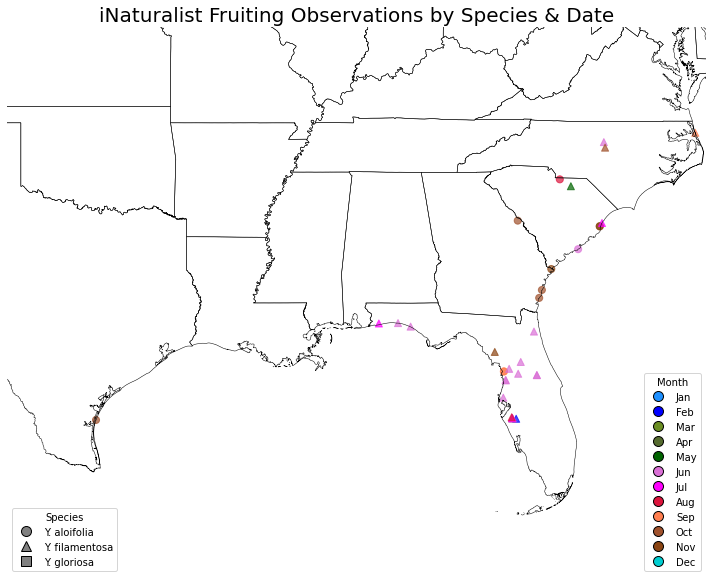

In [33]:
fig, ax = plt.subplots(figsize=(10,10))

states.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

# plot each species separately
for species, marker in marker_dict.items():
    if species in fruit["Species"].unique():

        sub = fruit[fruit["Species"] == species]

        sub.plot(
            ax=ax,
            column="Month",
            cmap=season_map,
            marker=marker,
            markersize=50,
            alpha=0.7,
            legend=False
        )

handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle="",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=10,
        label=species
    )
    for species, marker in marker_dict.items()
]

species_legend = ax.legend(
    handles=handles,
    title="Species",
    loc="lower left"
)
ax.add_artist(species_legend)

cmap = plt.get_cmap(season_map)

month_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=cmap((m-1)/11),
        markeredgecolor="black",
        markersize=10,
        label=calendar.month_abbr[m]
    )
    for m in range(1, 13)
]

ax.legend(
    handles=month_handles,
    title="Month",
    loc="lower right"
)

xmin, ymin, xmax, ymax = flower.total_bounds

ax.set_xlim(xmin - 3, xmax + 3)
ax.set_ylim(ymin - 3, ymax + 3)

ax.set_axis_off()

plt.title("iNaturalist Fruiting Observations by Species & Date",fontsize=20)
plt.tight_layout()

plt.savefig("./inat_fruiting_map.png",dpi=300,bbox_inches="tight")
plt.savefig("./inat_fruiting_map.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./inat_fruiting_map.svg",dpi=300,bbox_inches="tight")

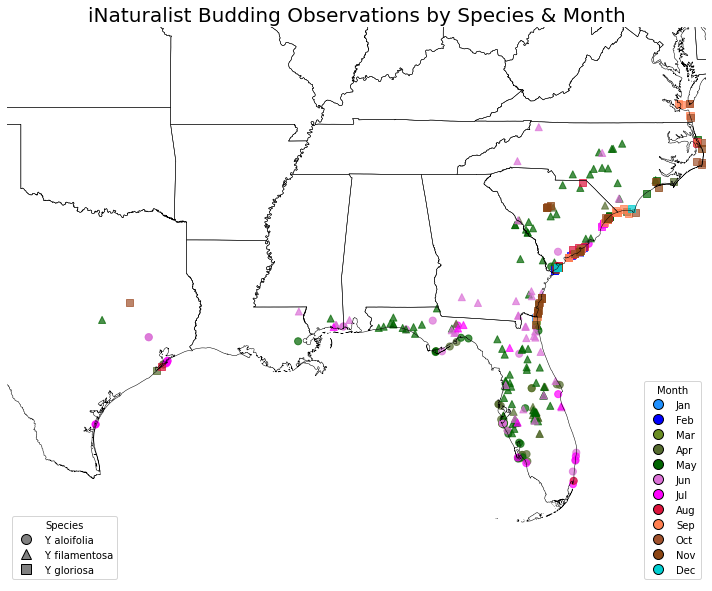

In [34]:
fig, ax = plt.subplots(figsize=(10,10))

states.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

# plot each species separately
for species, marker in marker_dict.items():

    sub = bud[bud["Species"] == species]

    sub.plot(
        ax=ax,
        column="Month",
        cmap=season_map,
        marker=marker,
        markersize=50,
        alpha=0.7,
        legend=False
    )

handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle="",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=10,
        label=species
    )
    for species, marker in marker_dict.items()
]

species_legend = ax.legend(
    handles=handles,
    title="Species",
    loc="lower left"
)
ax.add_artist(species_legend)

cmap = plt.get_cmap(season_map)

month_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=cmap((m-1)/11),
        markeredgecolor="black",
        markersize=10,
        label=calendar.month_abbr[m]
    )
    for m in range(1, 13)
]

ax.legend(
    handles=month_handles,
    title="Month",
    loc="lower right"
)

xmin, ymin, xmax, ymax = flower.total_bounds

ax.set_xlim(xmin - 3, xmax + 3)
ax.set_ylim(ymin - 3, ymax + 3)

ax.set_axis_off()

plt.title("iNaturalist Budding Observations by Species & Month",fontsize=20)
plt.tight_layout()

plt.savefig("./inat_budding_map.png",dpi=300,bbox_inches="tight")
plt.savefig("./inat_budding_map.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./inat_budding_map.svg",dpi=300,bbox_inches="tight")

## Section 2: Plot number of flowering observations by month & species

In [41]:
# this will probably be a bar plot
fbar = df[df["Flowering"]=="Yes"]

In [42]:
fbar.head()

,Species,Month,Year,Flowering,Fruit,Budding,Latitude,Longitude
0,Y. aloifolia,May,2010,Yes,No,No,30.029386,-81.336282
1,Y. aloifolia,May,2013,Yes,No,Yes,27.521692,-82.643475
2,Y. aloifolia,May,2013,Yes,No,Yes,26.915702,-82.091372
3,Y. aloifolia,Apr,2014,Yes,No,Yes,27.512260,-82.632043
5,Y. aloifolia,May,2015,Yes,No,Yes,30.074433,-84.180236


In [45]:
fcount = fbar.groupby(["Species","Month"]).count().reset_index()[["Species","Month","Flowering"]]
fcount.head()

,Species,Month,Flowering
0,Y. aloifolia,Apr,28
1,Y. aloifolia,Aug,6
2,Y. aloifolia,Feb,1
3,Y. aloifolia,Jul,26
4,Y. aloifolia,Jun,38


In [46]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

In [49]:
# set custom palette
custompal = {
    "Y. aloifolia":"gold",
    "Y. filamentosa":"blue",
    "Y. gloriosa":"turquoise"
}

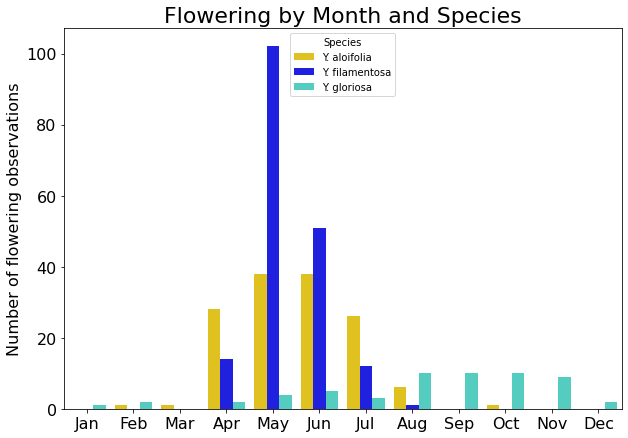

In [54]:
fig,ax = plt.subplots(figsize=(10,7))
sns.barplot(data=fcount,y="Flowering",x="Month",hue="Species",order=month_order,palette=custompal)

ax.tick_params(which="both",labelsize=16)
plt.ylabel("Number of flowering observations",fontsize=16)
plt.xlabel("")
plt.title("Flowering by Month and Species",fontsize=22)
plt.savefig("./flowering_time_barplot.png",dpi=300,bbox_inches="tight")
plt.savefig("./flowering_time_barplot.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./flowering_time_barplot.svg",dpi=300,bbox_inches="tight")
